Universidade Federal do ABC (UFABC)  
Curso: Bacharelado em Ciências Econômicas  
Disciplina: Economia Matemática  
Período: 2º Quadrimestre de 2026  
Turmas: Matutino (DA2ESHC027-21SB) e Noturno (NA2ESHC027-21SB)  
Prova 02: otimização com e sem restrição (Aulas 13 a 18) | Entrega: 14 de agosto de 2026 (sexta-feira) 
  
Prof. Dr. Elson Rodrigo de Souza Santos  
WhatsApp: (41) 9 8454 0549 | E-mail: elson129@gmail.com ou elson.rodrigo@ufabc.edu.br | Repositório: github.com/elsonr29  
14 de agosto de 2026  

RESOLUÇÃO DA PROVA 02

Observações:
    
1) Utilizamos o Python e os fundamentos da "quantitative economics", aula 40 -  Linear Programming e aula 41 - Shortest Paths < https://intro.quantecon.org/intro.html > ;   
2) Os resultados devem ser coerentes com os obtidos manualmente; 
3) O Python é uma forma inclusiva de demonstrar os conceitos e modelos apresentados e discutidos em sala de aula;  
4) Apresentamos a resolução análitica quando quantitativa;
5) Serve como base para justificativa da nota. 

## Prova 02

**Questão 1)** O objetivo do consumidor é maximizar o nível de satisfação descrito pela função de utilidade $U(x_1, x_2)$, sujeito à restrição orçamentária $p_1 x_1 + p_2 x_2 = I$. Considere a formalização:

$$\max_{x_1, x_2} U(x_1, x_2) = x_1 x_2 + 3 x_1 + 2 x_2 \quad \text{sujeito a} \quad x_1 + 4 x_2 = 90$$

A escolha ótima do consumidor é representada pelas quantidades dos bens ($x_1^*, x_2^*$), dados os respectivos preços ($p_1, p_2$) e a renda ($I$). Os preços e a renda são estritamente positivos ($p_1, p_2, I > 0$), enquanto o consumo dos bens obedece à restrição de não negatividade ($x_1^*, x_2^* \ge 0$).

a) Quais são as condições de primeira ordem (CPO)? Utilize a função de Lagrange, identifique o sistema de equações lineares, o formato de matriz ($Ax=d$) e verifique se o sistema possui solução única (Dica: determinante $|A| \neq 0$).

b) Calcule os pontos ótimos $x_1^*, x_2^*$ e o multiplicador de Lagrange $\lambda^*$ a partir das CPO.

c) Verifique as condições de segunda ordem (CSO) por meio da matriz hessiana orlada $\bar{H}$.

d) Demonstre que a relação abaixo é verdadeira. Sendo equivalente ao resultado obtido pelo método do multiplicador de Lagrange:

$$\frac{U_1}{p_1} = \frac{U_2}{p_2} = \lambda$$

e) Por que a restrição orçamentária é importante para garantir a existência de um ponto ótimo crível na maximização da utilidade? Como a mudança na restrição orçamentária (alteração nos preços ou na renda) afeta o ponto de otimização? (Dica: considere a correlação positiva entre renda e satisfação).

***

**Questão 2)** Considere uma economia com dois mercados perfeitamente competitivos e correlacionados para os bens $q_1$ e $q_2$. O governo impõe alíquotas específicas $t_1$ e $t_2$ sobre os produtores de cada respectivo setor, cujo objetivo é maximizar a receita total. 

A função objetivo corresponde à soma exata das arrecadações individuais, $R(t_1, t_2) = t_1 \cdot q_1(t_1, t_2) + t_2 \cdot q_2(t_1, t_2)$, formalizada por:

$$\max_{t_1, t_2} R(t_1, t_2) = 120 t_1 + 210 t_2 + 2 t_1 t_2 - 6 t_1^2 - 4 t_2^2$$

a) A partir da função objetivo, determine as Condições de Primeira Ordem (CPO). (Dica: $f_1 = 0$, $f_2 = 0$, então $f_1 = f_2$)

b) Calcule o ponto ótimo $(t_1^*, t_2^*)$. 

c) Verifique as Condições de Segunda Ordem (CSO) por meio da matriz hessiana. (Dica: sem orla, pois não há restrição)

d) Suponha que uma restrição política imponha que a alíquota do segundo mercado seja nula ($t_2 = 0$). Qual será o impacto sobre a escolha ótima do governo e sobre a arrecadação total? (Dica: os bens são substitutos imperfeitos)

e) As alíquotas e a receita tributária do governo tendem a ser menores na realidade do que o limite técnico. Um dos motivos são as restrições políticas (grupos de interesse e lobby, manutenção da base de apoio, por exemplo). Como podemos modelar essa restrição por meio do instrumental de otimização com restrição? 

**Obs.:** As respostas devem ter o rigor formal e teórico.

In [9]:
# Pacotes necessário para resolução

# Instação (se necessário)

!pip install numpy sympy matplotlib

#Obs.: Utilizamos o numpy para manipulação de matrizes e álgebra e o matplotlib para formatação de gráficos. Seguimos o caminho proposto pela Quantitative Economics.

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Carregamento

import numpy as np  
import sympy as sp
import matplotlib.pyplot as plt

# Obs.: após o carregamento é possível resolver a lista.

#### RESOLUÇÃO: QUESTÃO 1

Consideramos os dados:

\begin{equation}
	\max_{x_1, x_2} U(x_1, x_2) = x_1 x_2 + 3 x_1 + 2 x_2 \quad \text{sujeito a} \quad x_1 + 4 x_2 = 90
\end{equation}

* A escolha ótima do consumidor é representada pelas quantidades dos bens ($x_1^*, x_2^*$), dados os respectivos preços ($p_1, p_2$) e a renda ($I$); 
* Os preços e a renda são estritamente positivos ($p_1, p_2, I > 0$);
* O consumo dos bens obedece à restrição de não negatividade ($x_1^*, x_2^* \ge 0$).

Obs.: a função-objetivo é a utilidade que indica a satisfação do consumidor em adquirir bens. Enquanto a restrição orçamentária indica as combinações possíveis de serem objeto de escolha. 

#### a) Função de Lagrange, CPO, sistema linear e matriz ($Ax=d$).

**Função de Lagrange**

A função de Lagrange incorpora a restrição orçamentária à função objetivo por meio do multiplicador de Lagrange $\lambda$:

$$\mathcal{L}(x_1, x_2, \lambda) = x_1 x_2 + 3 x_1 + 2 x_2 + \lambda(90 - x_1 - 4 x_2)$$

**Condições de Primeira Ordem (CPO)**

As Condições de Primeira Ordem exigem que as derivadas parciais da função de Lagrange em relação a $x_1$, $x_2$ e $\lambda$ sejam iguais a zero:

1. $\frac{\partial \mathcal{L}}{\partial x_1} = x_2 + 3 - \lambda = 0$
2. $\frac{\partial \mathcal{L}}{\partial x_2} = x_1 + 2 - 4\lambda = 0$
3. $\frac{\partial \mathcal{L}}{\partial \lambda} = 90 - x_1 - 4x_2 = 0$

**Sistema de Equações Lineares**

Ao reorganizar as equações para manter as variáveis endógenas ($x_1, x_2, \lambda$) no lado esquerdo e transferir as constantes para o lado direito, obtemos o seguinte sistema linear:

* $0x_1 + 1x_2 - 1\lambda = -3$
* $1x_1 + 0x_2 - 4\lambda = -2$
* $1x_1 + 4x_2 + 0\lambda = 90$

**Formato de Matriz ($Ax = d$)**

No formato matricial, o sistema linear assume a seguinte estrutura:

$$ \begin{bmatrix} 0 & 1 & -1 \\ 1 & 0 & -4 \\ 1 & 4 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ \lambda \end{bmatrix} = \begin{bmatrix} -3 \\ -2 \\ 90 \end{bmatrix} $$

Onde:
* **$A$** é a matriz dos coeficientes.
* **$x$** é o vetor de variáveis.
* **$d$** é o vetor de constantes.

**Verificação de Solução Única pelo determinante via expansão de Laplace**

Para confirmar a existência de uma solução única e determinada, calculamos o determinante da matriz de coeficientes $A$ aplicando a expansão de Laplace na primeira linha:

$$|A| = 0 \cdot \det\begin{pmatrix} 0 & -4 \\ 4 & 0 \end{pmatrix} - 1 \cdot \det\begin{pmatrix} 1 & -4 \\ 1 & 0 \end{pmatrix} + (-1) \cdot \det\begin{pmatrix} 1 & 0 \\ 1 & 4 \end{pmatrix}$$

$$|A| = 0 - 1 \cdot (0 - (-4)) - 1 \cdot (4 - 0)$$

$$|A| = 0 - 4 - 4$$

$$|A| = -8$$

Como o determinante da matriz $A$ é diferente de zero ($|A| = -8 \neq 0$), a matriz é não singular. Esse resultado matemático assegura que o sistema de equações lineares possui uma solução exata e única para a cesta de consumo ótima.

Obs.: identificamos como chegar a solução e fundamentamos que existe e é única.

#### b) Pontos ótimos $x_1^*, x_2^*$ 

Para obter os pontos ótimos $x_1^*, x_2^*$ e o multiplicador de Lagrange $\lambda^*$ utilizamos a Regra de Cramer. A justificativa de que a matriz $|A| = -8$, sugerindo uma solução única e definida. Além disso, a regra de Cramer é a forma mais rápida de chegar aos pontos ótimos.

O sistema é dado por:
$$ \begin{bmatrix} 0 & 1 & -1 \\ 1 & 0 & -4 \\ 1 & 4 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ \lambda \end{bmatrix} = \begin{bmatrix} -3 \\ -2 \\ 90 \end{bmatrix} $$

A Regra de Cramer estabelece que a solução para cada variável é o quociente entre o determinante da matriz modificada (substituindo a coluna correspondente à variável pelo vetor de constantes $d$) e o determinante da matriz principal $|A|$.

**$x_1^*$**

Substituímos a primeira coluna de $A$ pelo vetor $d$:
$$ A_{x_1} = \begin{bmatrix} -3 & 1 & -1 \\ -2 & 0 & -4 \\ 90 & 4 & 0 \end{bmatrix} $$

Calculamos o determinante $|A_{x_1}|$ pela expansão da primeira linha:
$$ |A_{x_1}| = -3 \cdot \det\begin{pmatrix} 0 & -4 \\ 4 & 0 \end{pmatrix} - 1 \cdot \det\begin{pmatrix} -2 & -4 \\ 90 & 0 \end{pmatrix} + (-1) \cdot \det\begin{pmatrix} -2 & 0 \\ 90 & 4 \end{pmatrix} $$
$$ |A_{x_1}| = -3(0 - (-16)) - 1(0 - (-360)) - 1(-8 - 0) $$
$$ |A_{x_1}| = -3(16) - 1(360) + 8 $$
$$ |A_{x_1}| = -48 - 360 + 8 = -400 $$

Logo, a quantidade ótima do bem 1 é:
$$ x_1^* = \frac{|A_{x_1}|}{|A|} = \frac{-400}{-8} = 50 $$

**$x_2^*$**

Substituímos a segunda coluna de $A$ pelo vetor $d$:
$$ A_{x_2} = \begin{bmatrix} 0 & -3 & -1 \\ 1 & -2 & -4 \\ 1 & 90 & 0 \end{bmatrix} $$

Calculamos o determinante $|A_{x_2}|$:
$$ |A_{x_2}| = 0 - (-3) \cdot \det\begin{pmatrix} 1 & -4 \\ 1 & 0 \end{pmatrix} + (-1) \cdot \det\begin{pmatrix} 1 & -2 \\ 1 & 90 \end{pmatrix} $$
$$ |A_{x_2}| = 3(0 - (-4)) - 1(90 - (-2)) $$
$$ |A_{x_2}| = 3(4) - 1(92) $$
$$ |A_{x_2}| = 12 - 92 = -80 $$

Logo, a quantidade ótima do bem 2 é:
$$ x_2^* = \frac{|A_{x_2}|}{|A|} = \frac{-80}{-8} = 10 $$

**Cálculo de $\lambda^*$**

Substituímos a terceira coluna de $A$ pelo vetor $d$:
$$ A_{\lambda} = \begin{bmatrix} 0 & 1 & -3 \\ 1 & 0 & -2 \\ 1 & 4 & 90 \end{bmatrix} $$

Calculamos o determinante $|A_{\lambda}|$:
$$ |A_{\lambda}| = 0 - 1 \cdot \det\begin{pmatrix} 1 & -2 \\ 1 & 90 \end{pmatrix} + (-3) \cdot \det\begin{pmatrix} 1 & 0 \\ 1 & 4 \end{pmatrix} $$
$$ |A_{\lambda}| = -1(90 - (-2)) - 3(4 - 0) $$
$$ |A_{\lambda}| = -1(92) - 3(4) $$
$$ |A_{\lambda}| = -92 - 12 = -104 $$

Logo, o multiplicador de Lagrange é:
$$ \lambda^* = \frac{|A_{\lambda}|}{|A|} = \frac{-104}{-8} = 13 $$

**Conclusão**

Os pontos ótimos de consumo e o multiplicador de Lagrange que resolvem o problema de maximização são $x_1^* = 50$, $x_2^* = 10$ e $\lambda^* = 13$.

**Verificação**

Para verificar se os pontos ótimos são a solução substituimos no sistema linear das CPO

O sistema linear original estabelece as seguintes equações:

1. $0x_1 + 1x_2 - 1\lambda = -3$
2. $1x_1 + 0x_2 - 4\lambda = -2$
3. $1x_1 + 4x_2 + 0\lambda = 90$

**Verificação da primeira equação:**
$$0(50) + 1(10) - 1(13) = 10 - 13 = -3$$
A igualdade é perfeitamente satisfeita.

**Verificação da segunda equação:**
$$1(50) + 0(10) - 4(13) = 50 - 52 = -2$$
A igualdade é perfeitamente satisfeita.

**Verificação da terceira equação (restrição orçamentária):**
$$1(50) + 4(10) + 0(13) = 50 + 40 = 90$$
A igualdade é perfeitamente satisfeita.

Como todas as equações do sistema linear retornam resultados exatos, confirmamos matematicamente que o vetor $(50, 10, 13)$ representa a solução correta para o problema de otimização.




#### c) CSO e matriz hessiana orlada $\bar{H}$

Para verificar as Condições de Segunda Ordem (CSO) para um máximo local, construímos a matriz Hessiana orlada $\bar{H}$ e calculamos o seu determinante.

Primeiro, determinamos as derivadas parciais de segunda ordem da função de utilidade $U(x_1, x_2) = x_1 x_2 + 3x_1 + 2x_2$:
* $U_1 = x_2 + 3 \implies U_{11} = 0$ e $U_{12} = 1$
* $U_2 = x_1 + 2 \implies U_{22} = 0$ e $U_{21} = 1$

Em seguida, identificamos as derivadas parciais da restrição orçamentária $g(x_1, x_2) = x_1 + 4x_2 = 90$ em relação aos bens:
* $g_1 = p_1 = 1$
* $g_2 = p_2 = 4$

Matriz Hessiana orlada $\bar{H}$:
$$ \bar{H} = \begin{bmatrix} 0 & g_1 & g_2 \\ g_1 & U_{11} & U_{12} \\ g_2 & U_{21} & U_{22} \end{bmatrix} = \begin{bmatrix} 0 & 1 & 4 \\ 1 & 0 & 1 \\ 4 & 1 & 0 \end{bmatrix} $$

Calculamos o determinante de $\bar{H}$ pela expansão de Laplace na primeira linha:
$$ |\bar{H}| = 0 \cdot \det\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} - 1 \cdot \det\begin{pmatrix} 1 & 1 \\ 4 & 0 \end{pmatrix} + 4 \cdot \det\begin{pmatrix} 1 & 0 \\ 4 & 1 \end{pmatrix} $$
$$ |\bar{H}| = 0 - 1(0 - 4) + 4(1 - 0) $$
$$ |\bar{H}| = 0 - 1(-4) + 4(1) $$
$$ |\bar{H}| = 4 + 4 = 8 $$

A regra matemática para a Condição de Segunda Ordem em um problema de maximização com duas variáveis de escolha ($n=2$) e uma restrição de igualdade ($m=1$) exige que o determinante da matriz Hessiana orlada seja estritamente positivo ($|\bar{H}| > 0$).

Como $|\bar{H}| = 8 > 0$, a condição é plenamente satisfeita. Esse resultado comprova de forma rigorosa que o ponto ótimo $(x_1^* = 50, x_2^* = 10)$ maximiza a utilidade do consumidor.


#### d) Demonstrar $\frac{U_1}{p_1} = \frac{U_2}{p_2} = \lambda$

Para demonstrar a validade da relação proposta, partiremos da estrutura teórica do método de Lagrange e, em seguida, aplicaremos os valores numéricos encontrados no problema para comprovar a equivalência empírica.

**Demonstração Teórica**

A função de Lagrange genérica para o problema de maximização de utilidade com restrição orçamentária possui a seguinte forma:
$$\mathcal{L} = U(x_1, x_2) + \lambda(I - p_1 x_1 - p_2 x_2)$$

As Condições de Primeira Ordem (CPO) exigem que as derivadas parciais em relação aos bens $x_1$ e $x_2$ sejam nulas. Ao calcular essas derivadas, podemos isolar o multiplicador de Lagrange ($\lambda$) em ambas as equações:

*   Derivada em relação a $x_1$:
    $$\frac{\partial \mathcal{L}}{\partial x_1} = U_1 - \lambda p_1 = 0 \implies U_1 = \lambda p_1 \implies \lambda = \frac{U_1}{p_1}$$

*   Derivada em relação a $x_2$:
    $$\frac{\partial \mathcal{L}}{\partial x_2} = U_2 - \lambda p_2 = 0 \implies U_2 = \lambda p_2 \implies \lambda = \frac{U_2}{p_2}$$

Ao igualar as duas expressões resultantes, obtemos a relação fundamental do equilíbrio do consumidor:
$$\frac{U_1}{p_1} = \frac{U_2}{p_2} = \lambda$$

**2. Verificação Numérica (Equivalência)**

Para atestar que o resultado obtido é equivalente aos dados do problema, calculamos as utilidades marginais ($U_1$ e $U_2$) utilizando as quantidades ótimas encontradas anteriormente ($x_1^* = 50$ e $x_2^* = 10$).

A partir da função de utilidade $U(x_1, x_2) = x_1 x_2 + 3 x_1 + 2 x_2$, as utilidades marginais no ponto ótimo são:
*   $U_1 = x_2 + 3 \implies U_1 = 10 + 3 = 13$
*   $U_2 = x_1 + 2 \implies U_2 = 50 + 2 = 52$

Agora, substituímos esses valores de utilidade marginal e os respectivos preços definidos pela restrição orçamentária ($p_1 = 1$ e $p_2 = 4$) na relação teórica:
$$\frac{13}{1} = \frac{52}{4} = \lambda$$

Executando as divisões:
$$13 = 13 = \lambda$$

A igualdade é perfeita e o valor retornado coincide de forma exata com o multiplicador $\lambda^* = 13$ calculado via Regra de Cramer no item anterior. O resultado comprova que o consumidor maximiza a sua utilidade ao igualar o benefício marginal por unidade monetária gasta em ambos os bens.

#### e) Importância da restrição para a solução do problema de otimização do consumidor

É uma questão teórica para aproximar a solução do comportamento racional do agente no ambiente real.

O agente racional possui desejos de consumo que satisfazem suas preferências por meio da função utilidade. Pelo menos, segundo a versão do modelo apresentada, o agente vai buscar consumir quantidades infinitas caso não houvesse restrição, porque não haveria motivo para não preferir consumir mais, já que não colocamos nenhuma trava para esse comportamento.

Quando introduzimos a restrição orçamentária (preços e renda), impomos que existem combinações de bens possíveis. E, portanto, o agente deve escolher entre as combinações possíveis aquela que proporciona maior satisfação, sendo esse um ponto de máxima utilidade dada a restrição.

Obviamente, se a restrição mudar (preços relativos ou renda), o ponto ótimo também deve mudar, mesmo quando preservamos a mesma função utilidade.


**Obs.:** é uma questão em aberto. Pode haver n possibilidades de resposta. Permitindo o uso de formalização ou apenas de teoria aplicada nas respostas. 

In [8]:
#### RESOLUÇÃO EM PYTHON: QUESTÃO 1

# carregar os pacotes

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# a) 

# 1. Definindo as variáveis simbólicas
x1, x2, lam = sp.symbols('x1 x2 lambda')

# 2. Declarando a função de utilidade e a restrição
U = x1 * x2 + 3 * x1 + 2 * x2

# A restrição orçamentária é x1 + 4*x2 = 90, logo g = 90 - x1 - 4*x2
g = 90 - x1 - 4 * x2

# 3. Construindo a função de Lagrange
L = U + lam * g

# 4. Calculando as Condições de Primeira Ordem (CPO)
dL_dx1 = sp.diff(L, x1)
dL_dx2 = sp.diff(L, x2)
dL_dlam = sp.diff(L, lam)

print("--- Condições de Primeira Ordem ---")
print(f"1) dL/dx1 = {dL_dx1} = 0")
print(f"2) dL/dx2 = {dL_dx2} = 0")
print(f"3) dL/dlam = {dL_dlam} = 0\n")

# 5. Estruturando o sistema matricial Ax = d
# Equação 1: 0*x1 + 1*x2 - 1*lam = -3
# Equação 2: 1*x1 + 0*x2 - 4*lam = -2
# Equação 3: 1*x1 + 4*x2 + 0*lam = 90

A = np.array([
    [0, 1, -1],
    [1, 0, -4],
    [1, 4, 0]
], dtype=float)

d = np.array([-3, -2, 90], dtype=float)

# 6. Verificando o determinante de A
det_A = np.linalg.det(A)

print("--- Sistema Matricial Ax = d ---")
print("Matriz A:")
print(A)
print("\nVetor d:")
print(d)
print(f"\nDeterminante de A (|A|): {det_A:.2f}")

if not np.isclose(det_A, 0):
    print("\nO determinante é diferente de zero. O sistema possui solução única e determinada.")
else:
    print("\nO determinante é zero. O sistema não possui solução única.")

--- Condições de Primeira Ordem ---
1) dL/dx1 = -lambda + x2 + 3 = 0
2) dL/dx2 = -4*lambda + x1 + 2 = 0
3) dL/dlam = -x1 - 4*x2 + 90 = 0

--- Sistema Matricial Ax = d ---
Matriz A:
[[ 0.  1. -1.]
 [ 1.  0. -4.]
 [ 1.  4.  0.]]

Vetor d:
[-3. -2. 90.]

Determinante de A (|A|): -8.00

O determinante é diferente de zero. O sistema possui solução única e determinada.


In [5]:
# b)

# Resolvendo o sistema linear para encontrar o vetor de soluções [x1*, x2*, lambda*]

solucao = np.linalg.solve(A, d)

x1_star = solucao[0]
x2_star = solucao[1]
lam_star = solucao[2]

print("--- Solução Ótima do Consumidor ---")
print(f"Quantidade do bem 1 (x1*): {x1_star:.2f}")
print(f"Quantidade do bem 2 (x2*): {x2_star:.2f}")
print(f"Multiplicador de Lagrange (lambda*): {lam_star:.2f}")

--- Solução Ótima do Consumidor ---
Quantidade do bem 1 (x1*): 50.00
Quantidade do bem 2 (x2*): 10.00
Multiplicador de Lagrange (lambda*): 13.00


In [6]:
# c) 

# Extraindo as derivadas de segunda ordem da função utilidade
# Como dL/dx1 = x2 + 3 - lambda, as segundas derivadas diretas são nulas

U11 = sp.diff(dL_dx1 + lam, x1) 
U12 = sp.diff(dL_dx1 + lam, x2) 
U21 = sp.diff(dL_dx2 + 4*lam, x1) 
U22 = sp.diff(dL_dx2 + 4*lam, x2) 

# Coeficientes da restrição (preços)
p1 = 1
p2 = 4

# Construindo a Matriz Hessiana Orlada
H_bar = sp.Matrix([
    [0, p1, p2],
    [p1, U11, U12],
    [p2, U21, U22]
])

# Calculando o determinante da matriz orlada
det_H_bar = H_bar.det()

print("--- Condição de Segunda Ordem (CSO) ---")
print("Matriz Hessiana Orlada:")
sp.pprint(H_bar)

print(f"\nDeterminante (|H_bar|): {det_H_bar}")

if det_H_bar > 0:
    print("O determinante é estritamente positivo (|H_bar| > 0).")
    print("O ponto ótimo encontrado maximiza a utilidade do consumidor.")

--- Condição de Segunda Ordem (CSO) ---
Matriz Hessiana Orlada:
⎡0  1  4⎤
⎢       ⎥
⎢1  0  1⎥
⎢       ⎥
⎣4  1  0⎦

Determinante (|H_bar|): 8
O determinante é estritamente positivo (|H_bar| > 0).
O ponto ótimo encontrado maximiza a utilidade do consumidor.


In [7]:
# d) 

# Calculando as utilidades marginais (derivadas parciais de U em relação a x1 e x2)
U1_func = sp.diff(U, x1)
U2_func = sp.diff(U, x2)

# Substituindo os valores ótimos encontrados (x1* = 50, x2* = 10)
U1_val = U1_func.subs({x1: x1_star, x2: x2_star})
U2_val = U2_func.subs({x1: x1_star, x2: x2_star})

# Calculando as razões entre utilidade marginal e preço
razao_1 = U1_val / p1
razao_2 = U2_val / p2

print("--- Demonstração do Equilíbrio Marginal ---")
print(f"Utilidade Marginal do bem 1 (U1): {U1_val}")
print(f"Utilidade Marginal do bem 2 (U2): {U2_val}")

print(f"\nRazão U1/p1: {razao_1:.2f}")
print(f"Razão U2/p2: {razao_2:.2f}")
print(f"Multiplicador (lambda*): {lam_star:.2f}")

# Validando a identidade matemática
if float(razao_1) == float(razao_2) == float(lam_star):
    print("\nConclusão: A igualdade U1/p1 = U2/p2 = lambda é verdadeira.")
    print("O resultado do método de Lagrange garante a maximização por meio da equalização do benefício marginal por unidade monetária gasta.")

--- Demonstração do Equilíbrio Marginal ---
Utilidade Marginal do bem 1 (U1): 13.0000000000000
Utilidade Marginal do bem 2 (U2): 52.0000000000000

Razão U1/p1: 13.00
Razão U2/p2: 13.00
Multiplicador (lambda*): 13.00

Conclusão: A igualdade U1/p1 = U2/p2 = lambda é verdadeira.
O resultado do método de Lagrange garante a maximização por meio da equalização do benefício marginal por unidade monetária gasta.


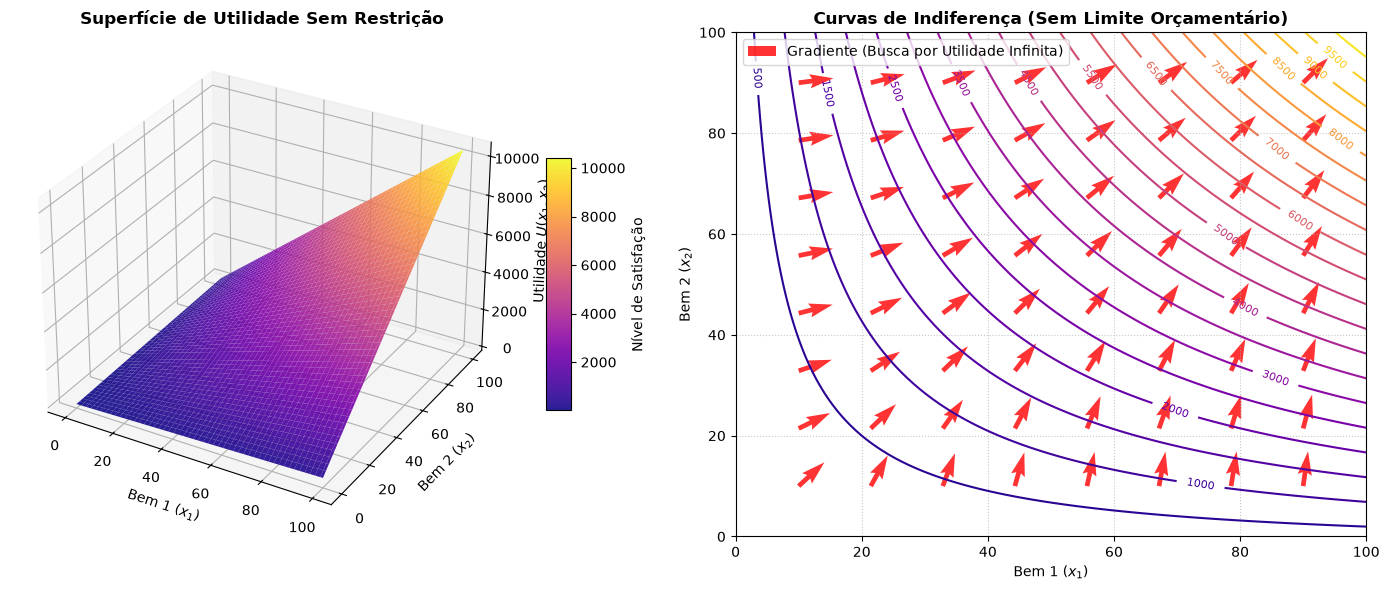

--- Resultado da Tentativa de Otimização Irrestrita ---
Status da Solução Numérica: Maximum number of function evaluations has been exceeded.
Observação: O algoritmo não converge para um ponto ótimo finito verdadeiro,
ele apenas para quando atinge limites de iteração ou overflow numérico,
comprovando a inexistência de solução sem restrição de orçamento.


In [11]:
# e)

# 1. Construção do domínio (quantidades simuladas de 0 a 100)
x1 = np.linspace(0, 100, 100)
x2 = np.linspace(0, 100, 100)
X1, X2 = np.meshgrid(x1, x2)

# 2. Cálculo da Utilidade em cada ponto da malha
U = X1 * X2 + 3 * X1 + 2 * X2

# 3. Configuração do ambiente gráfico
fig = plt.figure(figsize=(14, 6))

# --- Gráfico 1: Superfície de Utilidade 3D ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, U, cmap='plasma', edgecolor='none', alpha=0.9)
ax1.set_title('Superfície de Utilidade Sem Restrição', fontweight='bold')
ax1.set_xlabel('Bem 1 ($x_1$)')
ax1.set_ylabel('Bem 2 ($x_2$)')
ax1.set_zlabel('Utilidade $U(x_1, x_2)$')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Nível de Satisfação')

# --- Gráfico 2: Curvas de Indiferença e Gradiente (2D) ---
ax2 = fig.add_subplot(1, 2, 2)
contorno = ax2.contour(X1, X2, U, levels=20, cmap='plasma')
ax2.clabel(contorno, inline=True, fontsize=8, fmt='%.0f')

# Gerando vetores de gradiente para demonstrar a direção de maximização
x1_q = np.linspace(10, 90, 8)
x2_q = np.linspace(10, 90, 8)
X1_q, X2_q = np.meshgrid(x1_q, x2_q)

# As componentes do vetor gradiente são as utilidades marginais
U1_q = X2_q + 3  
U2_q = X1_q + 2  

# Normalizando os vetores para manter o tamanho das setas uniforme no gráfico
norma = np.sqrt(U1_q**2 + U2_q**2)
U1_q_norm = U1_q / norma
U2_q_norm = U2_q / norma

ax2.quiver(X1_q, X2_q, U1_q_norm, U2_q_norm, color='red', alpha=0.8, 
           label='Gradiente (Busca por Utilidade Infinita)')

ax2.set_title('Curvas de Indiferença (Sem Limite Orçamentário)', fontweight='bold')
ax2.set_xlabel('Bem 1 ($x_1$)')
ax2.set_ylabel('Bem 2 ($x_2$)')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# 4. Demonstração de falha na otimização via SciPy (Tentativa de achar máximo finito)
from scipy.optimize import minimize

# Função objetivo deve ser negativa pois o SciPy faz minimização por padrão
def utilidade_negativa(x):
    # Impor barreiras para não gerar erros numéricos no console
    if x[0] < 0 or x[1] < 0:
        return 0
    return -(x[0] * x[1] + 3 * x[0] + 2 * x[1])

chute_inicial = [10, 10]
resultado = minimize(utilidade_negativa, chute_inicial, method='Nelder-Mead')

print("--- Resultado da Tentativa de Otimização Irrestrita ---")
print("Status da Solução Numérica:", resultado.message)
print("Observação: O algoritmo não converge para um ponto ótimo finito verdadeiro,")
print("ele apenas para quando atinge limites de iteração ou overflow numérico,")
print("comprovando a inexistência de solução sem restrição de orçamento.")

# Obs.: estamos formalizando uma resposta possível 

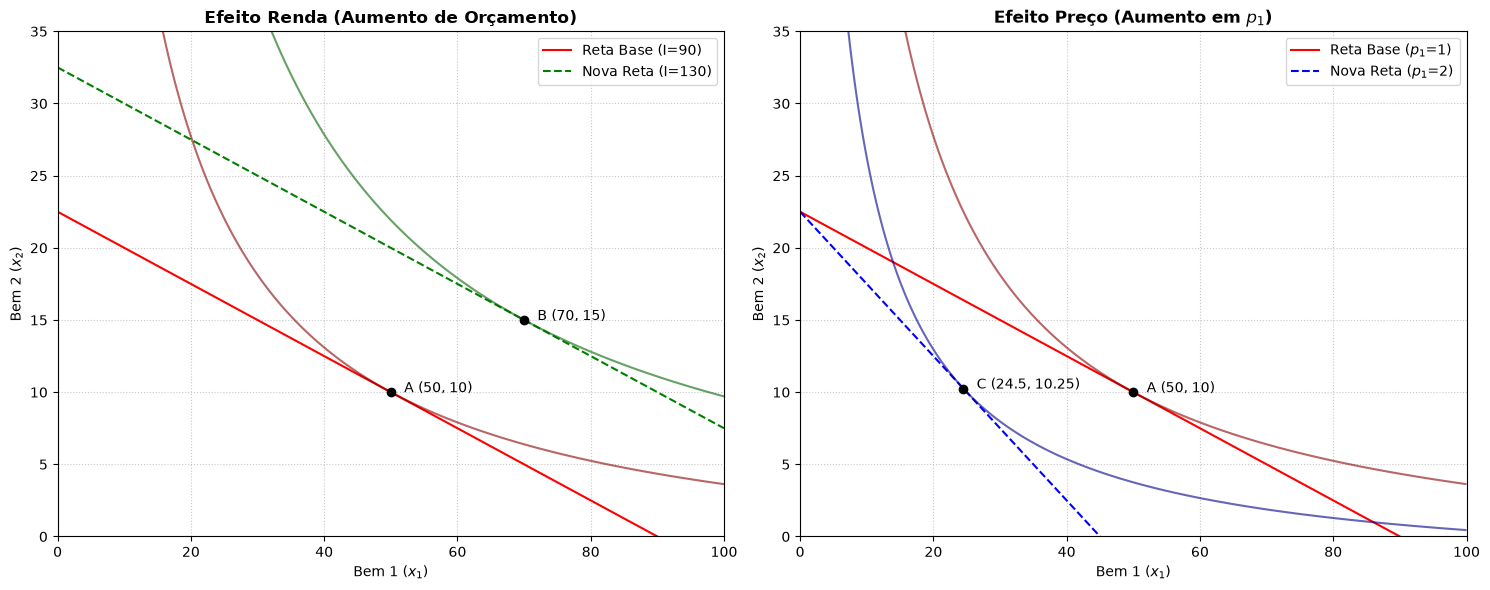

--- Resultados Analíticos da Simulação ---
Cenário Base (p1=1, p2=4, I=90):
  Ótimo A: x1* = 50.00, x2* = 10.00 | Utilidade = 670.00

Cenário Renda (p1=1, p2=4, I=130):
  Ótimo B: x1* = 70.00, x2* = 15.00 | Utilidade = 1290.00
  Impacto: A reta orçamentária sofre um deslocamento paralelo. O consumidor atinge uma curva de indiferença superior.

Cenário Preço (p1=2, p2=4, I=90):
  Ótimo C: x1* = 24.50, x2* = 10.25 | Utilidade = 345.12
  Impacto: A reta orçamentária rotaciona, reduzindo o poder de compra. A cesta ótima reflete o efeito substituição e o efeito renda negativos.


In [12]:
# e) continuação...

# Quanto alteramos os preços e a renda

# 1. Função para calcular o ponto ótimo analítico
# A partir das CPOs: (x2 + 3)/p1 = (x1 + 2)/p2 e p1*x1 + p2*x2 = I
# Chegamos às soluções fechadas:
def calcular_otimo(p1, p2, I):
    x1_star = (I + 3 * p2 - 2 * p1) / (2 * p1)
    x2_star = (I - 3 * p2 + 2 * p1) / (2 * p2)
    U_star = x1_star * x2_star + 3 * x1_star + 2 * x2_star
    return x1_star, x2_star, U_star

# 2. Definindo os Cenários
# Cenário Base
p1_base, p2_base, I_base = 1, 4, 90
x1_b, x2_b, U_b = calcular_otimo(p1_base, p2_base, I_base)

# Cenário A: Aumento de Renda (I = 130)
I_alta = 130
x1_r, x2_r, U_r = calcular_otimo(p1_base, p2_base, I_alta)

# Cenário B: Aumento do Preço do Bem 1 (p1 = 2)
p1_alto = 2
x1_p, x2_p, U_p = calcular_otimo(p1_alto, p2_base, I_base)

# 3. Configuração da Malha para as Curvas de Indiferença
x1 = np.linspace(0, 100, 400)
x2 = np.linspace(0, 40, 400)
X1, X2 = np.meshgrid(x1, x2)
U = X1 * X2 + 3 * X1 + 2 * X2

# 4. Construção dos Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfico 1: Efeito Renda ---
# Reta Orçamentária Base
x2_orc_base = (I_base - p1_base * x1) / p2_base
ax1.plot(x1, x2_orc_base, color='red', label=f'Reta Base (I={I_base})')

# Reta Orçamentária Alta Renda
x2_orc_renda = (I_alta - p1_base * x1) / p2_base
ax1.plot(x1, x2_orc_renda, color='green', linestyle='--', label=f'Nova Reta (I={I_alta})')

# Curvas de Indiferença nos pontos ótimos
ax1.contour(X1, X2, U, levels=[U_b], colors='darkred', alpha=0.6)
ax1.contour(X1, X2, U, levels=[U_r], colors='darkgreen', alpha=0.6)

# Pontos de equilíbrio
ax1.scatter([x1_b], [x2_b], color='black', zorder=5)
ax1.scatter([x1_r], [x2_r], color='black', zorder=5)
ax1.annotate(f'A ({x1_b:.0f}, {x2_b:.0f})', (x1_b + 2, x2_b))
ax1.annotate(f'B ({x1_r:.0f}, {x2_r:.0f})', (x1_r + 2, x2_r))

ax1.set_title('Efeito Renda (Aumento de Orçamento)', fontweight='bold')
ax1.set_xlabel('Bem 1 ($x_1$)')
ax1.set_ylabel('Bem 2 ($x_2$)')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 35)
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

# --- Gráfico 2: Efeito Preço ---
# Reta Orçamentária Base
ax2.plot(x1, x2_orc_base, color='red', label=f'Reta Base ($p_1$={p1_base})')

# Reta Orçamentária Preço Alto
x2_orc_preco = (I_base - p1_alto * x1) / p2_base
ax2.plot(x1, x2_orc_preco, color='blue', linestyle='--', label=f'Nova Reta ($p_1$={p1_alto})')

# Curvas de Indiferença nos pontos ótimos
ax2.contour(X1, X2, U, levels=[U_b], colors='darkred', alpha=0.6)
ax2.contour(X1, X2, U, levels=[U_p], colors='darkblue', alpha=0.6)

# Pontos de equilíbrio
ax2.scatter([x1_b], [x2_b], color='black', zorder=5)
ax2.scatter([x1_p], [x2_p], color='black', zorder=5)
ax2.annotate(f'A ({x1_b:.0f}, {x2_b:.0f})', (x1_b + 2, x2_b))
ax2.annotate(f'C ({x1_p:.1f}, {x2_p:.2f})', (x1_p + 2, x2_p))

ax2.set_title('Efeito Preço (Aumento em $p_1$)', fontweight='bold')
ax2.set_xlabel('Bem 1 ($x_1$)')
ax2.set_ylabel('Bem 2 ($x_2$)')
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 35)
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# 5. Exibição Numérica dos Resultados
print("--- Resultados Analíticos da Simulação ---")
print(f"Cenário Base (p1={p1_base}, p2={p2_base}, I={I_base}):")
print(f"  Ótimo A: x1* = {x1_b:.2f}, x2* = {x2_b:.2f} | Utilidade = {U_b:.2f}\n")

print(f"Cenário Renda (p1={p1_base}, p2={p2_base}, I={I_alta}):")
print(f"  Ótimo B: x1* = {x1_r:.2f}, x2* = {x2_r:.2f} | Utilidade = {U_r:.2f}")
print("  Impacto: A reta orçamentária sofre um deslocamento paralelo. O consumidor atinge uma curva de indiferença superior.\n")

print(f"Cenário Preço (p1={p1_alto}, p2={p2_base}, I={I_base}):")
print(f"  Ótimo C: x1* = {x1_p:.2f}, x2* = {x2_p:.2f} | Utilidade = {U_p:.2f}")
print("  Impacto: A reta orçamentária rotaciona, reduzindo o poder de compra. A cesta ótima reflete o efeito substituição e o efeito renda negativos.")

#### RESOLUÇÃO: QUESTÃO 2

Consideramos os dados:

A função objetivo corresponde à soma exata das arrecadações individuais, $R(t_1, t_2) = t_1 \cdot q_1(t_1, t_2) + t_2 \cdot q_2(t_1, t_2)$, formalizada por:

\begin{equation}
	\max_{t_1, t_2} R(t_1, t_2) = 120 t_1 + 210 t_2 + 2 t_1 t_2 - 6 t_1^2 - 4 t_2^2
\end{equation}


**a) CPO**

Para determinar as Condições de Primeira Ordem (CPO) da função objetivo, calculamos as derivadas parciais da função de arrecadação $R(t_1, t_2)$ em relação a cada uma das alíquotas de escolha ($t_1$ e $t_2$) e igualamos os resultados a zero. Este procedimento identifica os pontos críticos da função.

A função objetivo é dada por:
$$R(t_1, t_2) = 120 t_1 + 210 t_2 + 2 t_1 t_2 - 6 t_1^2 - 4 t_2^2$$

**1. Derivada parcial em relação a $t_1$ ($f_1 = 0$):**
$$f_1 = \frac{\partial R}{\partial t_1} = 120 + 2t_2 - 12t_1 = 0$$

**2. Derivada parcial em relação a $t_2$ ($f_2 = 0$):**
$$f_2 = \frac{\partial R}{\partial t_2} = 210 + 2t_1 - 8t_2 = 0$$

A partir dessas derivadas parciais, organizamos o sistema de equações lineares mantendo as variáveis endógenas de um lado da igualdade e as constantes do outro:

*   $12t_1 - 2t_2 = 120$
*   $-2t_1 + 8t_2 = 210$

Definimos a relação matricial no formato $Ax = d$, em que $A$ representa a matriz de coeficientes, $x$ o vetor das variáveis de escolha e $d$ o vetor de termos independentes:

$$ \begin{bmatrix} 12 & -2 \\ -2 & 8 \end{bmatrix} \begin{bmatrix} t_1 \\ t_2 \end{bmatrix} = \begin{bmatrix} 120 \\ 210 \end{bmatrix} $$

Para atestar matematicamente que este sistema possui uma solução exata e única, calculamos o determinante da matriz de coeficientes $A$:

$$ |A| = (12 \cdot 8) - (-2 \cdot -2) $$
$$ |A| = 96 - 4 $$
$$ |A| = 92 $$

Como o determinante da matriz $A$ é estritamente diferente de zero ($|A| = 92 \neq 0$), a matriz é classificada como não singular. Este resultado teórico garante a existência de uma solução única e perfeitamente determinada para o ponto ótimo de arrecadação tributária do governo.

Obs.: não existe uma restrição explicita. Portanto, o problema do governo é como achar o ponto ótimo $R(t_1, t_2)$ que garante a maior receita.

b) Ponto ótimo $R(t_1, t_2)$ via Regra de Cramer

Para calcular o ponto ótimo $(t_1^*, t_2^*)$, aplicamos a Regra de Cramer ao sistema matricial estruturado no item anterior.

A matriz de coeficientes $A$, o vetor de constantes $d$ e o determinante da matriz principal $|A|$ são:
$$ A = \begin{bmatrix} 12 & -2 \\ -2 & 8 \end{bmatrix}, \quad d = \begin{bmatrix} 120 \\ 210 \end{bmatrix}, \quad |A| = 92 $$

A Regra de Cramer determina que a solução para cada variável de escolha corresponde ao quociente entre o determinante da matriz modificada e o determinante da matriz principal.

**1. Cálculo de $t_1^*$**

Substituímos a primeira coluna de $A$ pelo vetor $d$ para encontrar $A_{t_1}$:
$$ A_{t_1} = \begin{bmatrix} 120 & -2 \\ 210 & 8 \end{bmatrix} $$

O cálculo do determinante resulta em:
$$ |A_{t_1}| = (120 \cdot 8) - (-2 \cdot 210) $$
$$ |A_{t_1}| = 960 - (-420) $$
$$ |A_{t_1}| = 1380 $$

Portanto, a alíquota ótima para o primeiro setor é:
$$ t_1^* = \frac{|A_{t_1}|}{|A|} = \frac{1380}{92} = 15 $$

**2. Cálculo de $t_2^*$**

Substituímos a segunda coluna de $A$ pelo vetor $d$ para encontrar $A_{t_2}$:
$$ A_{t_2} = \begin{bmatrix} 12 & 120 \\ -2 & 210 \end{bmatrix} $$

O cálculo do determinante resulta em:
$$ |A_{t_2}| = (12 \cdot 210) - (120 \cdot -2) $$
$$ |A_{t_2}| = 2520 - (-240) $$
$$ |A_{t_2}| = 2760 $$

Portanto, a alíquota ótima para o segundo setor é:
$$ t_2^* = \frac{|A_{t_2}|}{|A|} = \frac{2760}{92} = 30 $$

**Ponto ótimo**

O ponto ótimo que maximiza a receita total do governo possui o formato exato de $(t_1^*, t_2^*) = (15, 30)$.

**c) CSO e matriz hessiana 

Para verificar as Condições de Segunda Ordem (CSO) neste problema de otimização irrestrita, devemos construir a matriz Hessiana $H$ e avaliar os sinais dos seus menores principais. Este procedimento confirma matematicamente se o ponto crítico encontrado representa um máximo, um mínimo ou um ponto de sela.

A partir das derivadas de primeira ordem obtidas anteriormente:
*   $f_1 = 120 + 2t_2 - 12t_1$
*   $f_2 = 210 + 2t_1 - 8t_2$

Calculamos as derivadas parciais de segunda ordem diretas e cruzadas:
*   $f_{11} = \frac{\partial^2 R}{\partial t_1^2} = -12$
*   $f_{12} = \frac{\partial^2 R}{\partial t_1 \partial t_2} = 2$
*   $f_{21} = \frac{\partial^2 R}{\partial t_2 \partial t_1} = 2$
*   $f_{22} = \frac{\partial^2 R}{\partial t_2^2} = -8$

Com esses valores, estruturamos a matriz Hessiana $H$:
$$ H = \begin{bmatrix} f_{11} & f_{12} \\ f_{21} & f_{22} \end{bmatrix} = \begin{bmatrix} -12 & 2 \\ 2 & -8 \end{bmatrix} $$

Para atestar a existência de um ponto de máximo, a matriz Hessiana deve ser negativa definida. Isso exige que os determinantes dos menores principais alternem de sinal, começando estritamente com um valor negativo:
1.  **Primeiro menor principal ($|H_1|$):**
    $$ |H_1| = f_{11} = -12 < 0 $$
2.  **Segundo menor principal ($|H_2|$ ou $|H|$):**
    $$ |H_2| = (-12 \cdot -8) - (2 \cdot 2) $$
    $$ |H_2| = 96 - 4 $$
    $$ |H_2| = 92 > 0 $$

Como as condições matemáticas são perfeitamente atendidas ($|H_1| < 0$ e $|H_2| > 0$), a matriz Hessiana é classificada como negativa definida. Concluímos que o ponto ótimo $(t_1^* = 15, t_2^* = 30)$ maximiza a receita tributária do governo.

Obs.: matriz hessiana sem orla, pois não existe restrição.

**d) Se $t_2=0$**

Para avaliar o impacto da restrição política, incorporamos a condição $t_2 = 0$ diretamente na função objetivo original. Essa intervenção elimina as fontes de receita originadas no segundo mercado e extingue o termo de interação entre as alíquotas.

A nova função objetivo restrita é:
$$ R(t_1, 0) = 120 t_1 - 6 t_1^2 $$

**Nova Escolha Ótima ($t_1^*$)**

Calculamos a Condição de Primeira Ordem (CPO) para a nova função matemática:
$$ \frac{d R}{d t_1} = 120 - 12t_1 = 0 $$
$$ 12t_1 = 120 $$
$$ t_1^* = 10 $$

A escolha ótima do governo para o primeiro setor sofreu uma queda de $15$ (cenário irrestrito) para $10$.

**Impacto na Arrecadação Total**

Para mensurar o choque na receita, comparamos o cenário ótimo inicial com o cenário restrito.

**Arrecadação no cenário irrestrito ($t_1^* = 15$, $t_2^* = 30$):**
$$ R(15, 30) = 120(15) + 210(30) + 2(15)(30) - 6(15^2) - 4(30^2) $$
$$ R(15, 30) = 1800 + 6300 + 900 - 6(225) - 4(900) $$
$$ R(15, 30) = 9000 - 1350 - 3600 = 4050 $$

**Arrecadação no cenário restrito ($t_1^* = 10$, $t_2^* = 0$):**
$$ R(10, 0) = 120(10) - 6(10^2) $$
$$ R(10, 0) = 1200 - 6(100) $$
$$ R(10, 0) = 1200 - 600 = 600 $$

**Análise Econômica do Impacto**

A imposição política causa um colapso da arrecadçaão, resultando em uma redução da receita total de $4050$ para $600$. O motivo é que a tributação impõe a mudança de preços relativos em favor do mercado do bem 2. Dessa forma, o agente tende a escolher o bem 2 em relação ao bem 1, reduzindo a qauntidade do bem tributado e a arrecadação. Ao mesmo tempo em que impõe ao governo a necessidade de reduzir o imposto sobre o bem 1 para otimizar a receita. 

**e) restrição sobre a capacidade de tributar**

Para modelar essa realidade com o instrumental de otimização restrita, devemos alterar o formato original do problema governamental. O governo deixa de focar apenas na maximização técnica da receita e passa a enfrentar uma restrição formal de economia política.

Podemos representar a pressão dos grupos de interesse e a necessidade de manutenção da base de apoio por meio de uma função de apoio político $S(t_1, t_2)$. Como os eleitores e os lobistas rejeitam a elevação da carga tributária, essa função possui derivadas parciais estritamente negativas em relação às alíquotas ($S_1 < 0$ e $S_2 < 0$).

O formulador de políticas precisa garantir um nível mínimo de apoio político $\bar{S}$ para manter o seu mandato, aprovar reformas ou evitar retaliações legislativas. A nova formulação matemática do modelo passa a ser:

$$ \max_{t_1, t_2} R(t_1, t_2) \quad \text{sujeito a} \quad S(t_1, t_2) \ge \bar{S} $$

A função de Lagrange incorpora a restrição política ao objetivo original de arrecadação:

$$ \mathcal{L}(t_1, t_2, \lambda) = R(t_1, t_2) + \lambda(S(t_1, t_2) - \bar{S}) $$

As Condições de Primeira Ordem (CPO) demonstram a nova dinâmica de escolha:

1.  $\frac{\partial \mathcal{L}}{\partial t_1} = R_1 + \lambda S_1 = 0 \implies R_1 = -\lambda S_1$
2.  $\frac{\partial \mathcal{L}}{\partial t_2} = R_2 + \lambda S_2 = 0 \implies R_2 = -\lambda S_2$

Neste arcabouço, o multiplicador de Lagrange ($\lambda$) atua como o preço sombra da restrição política. Ele mensura a exata quantidade de receita tributária marginal que o governo aceita sacrificar para preservar uma unidade marginal de apoio político. 

Como a restrição política é ativa antes de o governo alcançar o topo da Curva de Laffer, o valor de $\lambda$ é estritamente positivo ($\lambda > 0$). Essa estrutura força o governo a interromper a elevação dos impostos antes do limite técnico de arrecadação. No novo ponto ótimo, a receita marginal de um aumento de impostos iguala o custo político marginal ponderado por $\lambda$. Portanto, as alíquotas de equilíbrio no ambiente real serão invariavelmente menores que as alíquotas do cenário puramente irrestrito.

Obs.: é uma das possíveis respostas para questão.

In [13]:
#### RESOLUÇÃO EM PYTHON: QUESTÃO 2

# carregar os pacotes

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# a)

# 1. Definindo as variáveis simbólicas
t1, t2 = sp.symbols('t1 t2')

# 2. Declarando a função objetivo de arrecadação
R = 120 * t1 + 210 * t2 + 2 * t1 * t2 - 6 * t1**2 - 4 * t2**2

# 3. Calculando as derivadas parciais (Condições de Primeira Ordem)
f1 = sp.diff(R, t1)
f2 = sp.diff(R, t2)

print("--- Condições de Primeira Ordem (CPO) ---")
print(f"f1 = dR/dt1 = {f1} = 0")
print(f"f2 = dR/dt2 = {f2} = 0\n")

# 4. Igualando f1 e f2 (f1 = f2)
print("--- Relação f1 = f2 ---")
print(f"{f1} = {f2}")

# Simplificando a igualdade (f1 - f2 = 0)
relacao = sp.simplify(f1 - f2)
print(f"Equação unificada: {relacao} = 0\n")

# 5. Estruturando o sistema matricial Ax = d
# Equação 1: 12*t1 - 2*t2 = 120
# Equação 2: -2*t1 + 8*t2 = 210

A = np.array([
    [12, -2],
    [-2, 8]
], dtype=float)

d = np.array([120, 210], dtype=float)

# 6. Calculando o determinante da matriz A
det_A = np.linalg.det(A)

print("--- Sistema Matricial Ax = d ---")
print("Matriz A:")
print(A)
print("\nVetor d:")
print(d)
print(f"\nDeterminante de A (|A|): {det_A:.0f}")

if not np.isclose(det_A, 0):
    print("\nO determinante é diferente de zero. A matriz é não singular e o sistema possui solução única.")
else:
    print("\nO determinante é zero. O sistema não possui solução única.")

--- Condições de Primeira Ordem (CPO) ---
f1 = dR/dt1 = -12*t1 + 2*t2 + 120 = 0
f2 = dR/dt2 = 2*t1 - 8*t2 + 210 = 0

--- Relação f1 = f2 ---
-12*t1 + 2*t2 + 120 = 2*t1 - 8*t2 + 210
Equação unificada: -14*t1 + 10*t2 - 90 = 0

--- Sistema Matricial Ax = d ---
Matriz A:
[[12. -2.]
 [-2.  8.]]

Vetor d:
[120. 210.]

Determinante de A (|A|): 92

O determinante é diferente de zero. A matriz é não singular e o sistema possui solução única.


In [15]:
# b) 

# 1. Definindo a matriz de coeficientes (A) e o vetor de constantes (d)
A = np.array([
    [12, -2],
    [-2, 8]
], dtype=float)

d = np.array([120, 210], dtype=float)

# 2. Calculando o determinante da matriz principal |A|
det_A = np.linalg.det(A)

print("--- Regra de Cramer ---")
print(f"Determinante principal (|A|): {det_A:.0f}\n")

# 3. Calculando t1_star
# Criamos uma cópia da matriz A e substituímos a primeira coluna pelo vetor d
A_t1 = A.copy()
A_t1[:, 0] = d

det_A_t1 = np.linalg.det(A_t1)
t1_star = det_A_t1 / det_A

print("Matriz modificada para t1 (A_t1):")
print(A_t1)
print(f"Determinante (|A_t1|): {det_A_t1:.0f}")
print(f"Alíquota ótima do setor 1 (t1*) = {det_A_t1:.0f} / {det_A:.0f} = {t1_star:.0f}\n")

# 4. Calculando t2_star
# Criamos uma cópia da matriz A e substituímos a segunda coluna pelo vetor d
A_t2 = A.copy()
A_t2[:, 1] = d

det_A_t2 = np.linalg.det(A_t2)
t2_star = det_A_t2 / det_A

print("Matriz modificada para t2 (A_t2):")
print(A_t2)
print(f"Determinante (|A_t2|): {det_A_t2:.0f}")
print(f"Alíquota ótima do setor 2 (t2*) = {det_A_t2:.0f} / {det_A:.0f} = {t2_star:.0f}\n")

# 5. Conclusão
print("--- Ponto Ótimo ---")
print(f"O ponto ótimo de tributação é (t1*, t2*) = ({t1_star:.0f}, {t2_star:.0f})")

--- Regra de Cramer ---
Determinante principal (|A|): 92

Matriz modificada para t1 (A_t1):
[[120.  -2.]
 [210.   8.]]
Determinante (|A_t1|): 1380
Alíquota ótima do setor 1 (t1*) = 1380 / 92 = 15

Matriz modificada para t2 (A_t2):
[[ 12. 120.]
 [ -2. 210.]]
Determinante (|A_t2|): 2760
Alíquota ótima do setor 2 (t2*) = 2760 / 92 = 30

--- Ponto Ótimo ---
O ponto ótimo de tributação é (t1*, t2*) = (15, 30)


In [ ]:
# c) 

# 1. Definindo as variáveis simbólicas
t1, t2 = sp.symbols('t1 t2')

# 2. Declarando a função objetivo de arrecadação
R = 120 * t1 + 210 * t2 + 2 * t1 * t2 - 6 * t1**2 - 4 * t2**2

# 3. Calculando as derivadas parciais de primeira ordem
f1 = sp.diff(R, t1)
f2 = sp.diff(R, t2)

# 4. Calculando as derivadas parciais de segunda ordem
f11 = sp.diff(f1, t1)
f12 = sp.diff(f1, t2)
f21 = sp.diff(f2, t1)
f22 = sp.diff(f2, t2)

# 5. Construindo a matriz Hessiana (sem orla)
H = sp.Matrix([
    [f11, f12],
    [f21, f22]
])

print("--- Matriz Hessiana (H) ---")
sp.pprint(H)

# 6. Extraindo e calculando os menores principais
# O primeiro menor principal (|H1|) é o elemento da primeira linha e primeira coluna
H1 = H[0, 0]

# O segundo menor principal (|H2|) é o determinante da própria matriz 2x2
H2 = H.det()

print("\n--- Verificação das Condições de Segunda Ordem (CSO) ---")
print(f"Primeiro menor principal (|H1|): {H1}")
print(f"Segundo menor principal (|H2|): {H2}")

# 7. Validação matemática para ponto de máximo
if H1 < 0 and H2 > 0:
    print("\nConclusão:")
    print("Como os menores principais alternam de sinal, começando estritamente negativo (|H1| < 0 e |H2| > 0), a matriz Hessiana é negativa definida.")
    print("O ponto crítico (t1* = 15, t2* = 30) maximiza a receita tributária do governo.")
else:
    print("\nConclusão:")
    print("A matriz não é negativa definida. O ponto não representa um máximo.")

--- Matriz Hessiana (H) ---
⎡-12  2 ⎤
⎢       ⎥
⎣ 2   -8⎦

--- Verificação das Condições de Segunda Ordem (CSO) ---
Primeiro menor principal (|H1|): -12
Segundo menor principal (|H2|): 92

Conclusão Matemática:
Como os menores principais alternam de sinal, começando estritamente negativo (|H1| < 0 e |H2| > 0), a matriz Hessiana é negativa definida.
O ponto crítico (t1* = 15, t2* = 30) maximiza a receita tributária do governo.


In [19]:
# d) 

# 1. Definindo as variaveis e a funcao original
t1, t2 = sp.symbols('t1 t2')
R_original = 120 * t1 + 210 * t2 + 2 * t1 * t2 - 6 * t1**2 - 4 * t2**2

# Calculando a receita do cenario irrestrito para futura comparacao (t1=15, t2=30)
receita_irrestrita = R_original.subs({t1: 15, t2: 30})

# 2. Impondo a restricao politica (t2 = 0)
R_restrito = R_original.subs({t2: 0})
print("--- Nova Funcao Objetivo Restrita ---")
print(f"R(t1, 0) = {R_restrito}\n")

# 3. Condicao de Primeira Ordem (CPO)
f1 = sp.diff(R_restrito, t1)
print("--- Condicao de Primeira Ordem (CPO) ---")
print(f"dR/dt1 = {f1} = 0")
print("Ao isolar a variavel, obtemos a equacao: 12*t1 = 120\n")

# 4. Estruturando o sistema Ax = d e aplicando a Regra de Cramer (1x1)
A = np.array([[12]], dtype=float)
d = np.array([[120]], dtype=float)

# Determinante da matriz principal
det_A = np.linalg.det(A)

# Matriz modificada para t1
A_t1 = A.copy()
A_t1[:, 0] = d[:, 0]
det_A_t1 = np.linalg.det(A_t1)

t1_star = det_A_t1 / det_A

print("--- Sistema Matricial e Regra de Cramer ---")
print(f"Matriz A: {A}")
print(f"Vetor d: {d}")
print(f"Determinante principal (|A|): {det_A:.0f}")
print(f"Determinante modificado (|A_t1|): {det_A_t1:.0f}")
print(f"Aliquota otima restrita (t1*) = {det_A_t1:.0f} / {det_A:.0f} = {t1_star:.0f}\n")

# 5. Condicao de Segunda Ordem (CSO) e Matriz Hessiana
f11 = sp.diff(f1, t1)
H = sp.Matrix([[f11]])

print("--- Condicao de Segunda Ordem (CSO) ---")
print("Matriz Hessiana H (1x1):")
sp.pprint(H)

if H[0, 0] < 0:
    print(f"\nO determinante do primeiro menor principal e {H[0,0]} < 0.")
    print("A matriz e negativa definida. O ponto (t1=10) representa o novo maximo global.\n")

# 6. Avaliacao do Impacto Economico
receita_restrita = R_restrito.subs({t1: t1_star})
perda = receita_irrestrita - receita_restrita

print("--- Impacto na Arrecadacao Total ---")
print(f"Receita Original Irrestrita : {receita_irrestrita:.0f}")
print(f"Receita Nova Restrita       : {receita_restrita:.0f}")
print(f"Perda de Arrecadacao        : {perda:.0f}")

--- Nova Funcao Objetivo Restrita ---
R(t1, 0) = -6*t1**2 + 120*t1

--- Condicao de Primeira Ordem (CPO) ---
dR/dt1 = 120 - 12*t1 = 0
Ao isolar a variavel, obtemos a equacao: 12*t1 = 120

--- Sistema Matricial e Regra de Cramer ---
Matriz A: [[12.]]
Vetor d: [[120.]]
Determinante principal (|A|): 12
Determinante modificado (|A_t1|): 120
Aliquota otima restrita (t1*) = 120 / 12 = 10

--- Condicao de Segunda Ordem (CSO) ---
Matriz Hessiana H (1x1):
[-12]

O determinante do primeiro menor principal e -12 < 0.
A matriz e negativa definida. O ponto (t1=10) representa o novo maximo global.

--- Impacto na Arrecadacao Total ---
Receita Original Irrestrita : 4050
Receita Nova Restrita       : 600
Perda de Arrecadacao        : 3450


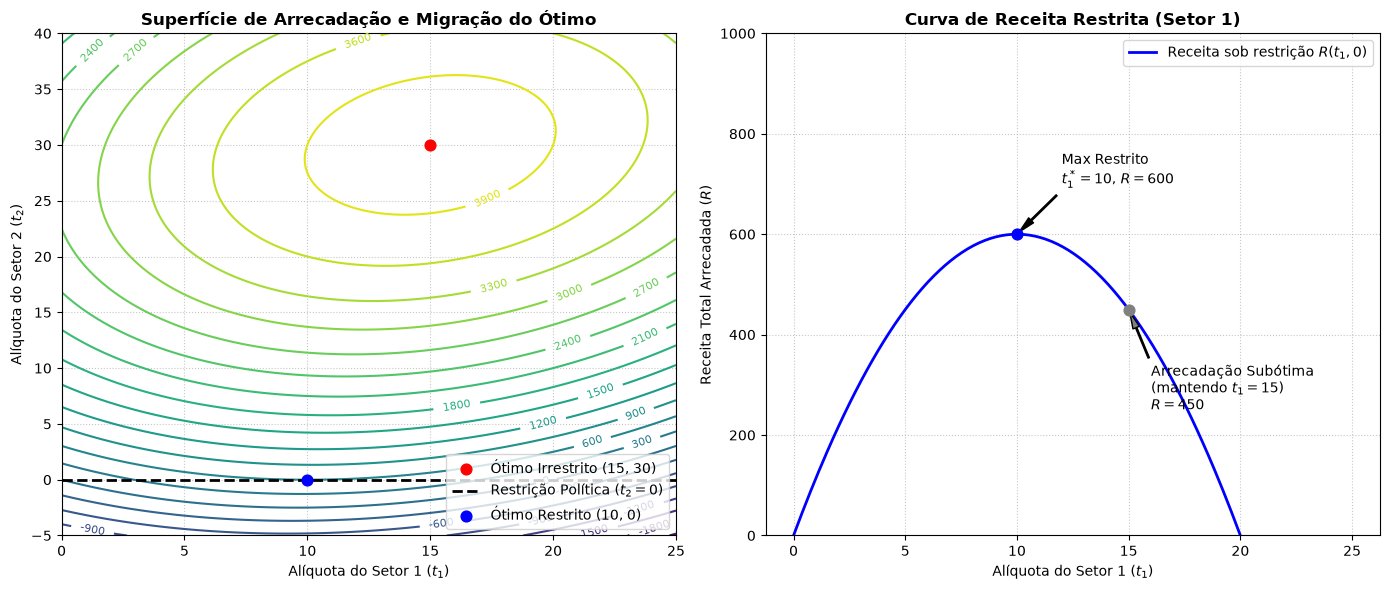

In [20]:
# d) continuação...

# Gráfico

# 1. Definindo o domínio das alíquotas para a malha
t1 = np.linspace(0, 25, 200)
# Utilizamos um domínio levemente negativo em t2 para facilitar a visualização do eixo t2=0
t2 = np.linspace(-5, 40, 200) 
T1, T2 = np.meshgrid(t1, t2)

# 2. Calculando a função de arrecadação irrestrita original
R = 120 * T1 + 210 * T2 + 2 * T1 * T2 - 6 * T1**2 - 4 * T2**2

# 3. Configuração do ambiente gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Curvas de Nível (Contour) do Cenário Irrestrito ---
contorno = ax1.contour(T1, T2, R, levels=20, cmap='viridis')
ax1.clabel(contorno, inline=True, fontsize=8, fmt='%.0f')

# Marcando o ponto ótimo irrestrito original
ax1.scatter(15, 30, color='red', zorder=5, s=60, label='Ótimo Irrestrito (15, 30)')

# Destacando a restrição política imposta (t2 = 0)
ax1.axhline(0, color='black', linestyle='--', linewidth=2, label='Restrição Política ($t_2=0$)')

# Marcando o novo ponto ótimo sob a restrição
ax1.scatter(10, 0, color='blue', zorder=5, s=60, label='Ótimo Restrito (10, 0)')

ax1.set_title('Superfície de Arrecadação e Migração do Ótimo', fontweight='bold')
ax1.set_xlabel('Alíquota do Setor 1 ($t_1$)')
ax1.set_ylabel('Alíquota do Setor 2 ($t_2$)')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle=':', alpha=0.7)

# --- Gráfico 2: Arrecadação Exclusiva sob a Restrição (t2 = 0) ---
# Função restrita: R(t1, 0) = 120*t1 - 6*t1^2
R_restrito = 120 * t1 - 6 * t1**2

ax2.plot(t1, R_restrito, color='blue', linewidth=2, label='Receita sob restrição $R(t_1, 0)$')

# Marcando o pico de arrecadação da função restrita
ax2.scatter(10, 600, color='blue', zorder=5, s=60)
ax2.annotate('Max Restrito\n$t_1^*=10$, $R=600$', xy=(10, 600), xytext=(12, 700),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# Marcando projetivamente a ineficiência caso o governo mantivesse t1 = 15
R_15_restrito = 120 * 15 - 6 * 15**2 
ax2.scatter(15, 450, color='gray', zorder=5, s=60)
ax2.annotate('Arrecadação Subótima\n(mantendo $t_1=15$)\n$R=450$', xy=(15, 450), xytext=(16, 250),
             arrowprops=dict(facecolor='gray', shrink=0.05, width=1, headwidth=5))

ax2.set_title('Curva de Receita Restrita (Setor 1)', fontweight='bold')
ax2.set_xlabel('Alíquota do Setor 1 ($t_1$)')
ax2.set_ylabel('Receita Total Arrecadada ($R$)')
ax2.set_ylim(0, 1000) 
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


--- Solução do Modelo de Economia Política ---
Alíquota t1 ótima (restrita) : 6.67
Alíquota t2 ótima (restrita) : 18.33
Multiplicador (lambda)       : 76.67

Receita Técnica (Irrestrita) : 4050.00
Receita Política (Restrita)  : 3283.33
Custo do Lobby (Perda)       : 766.67



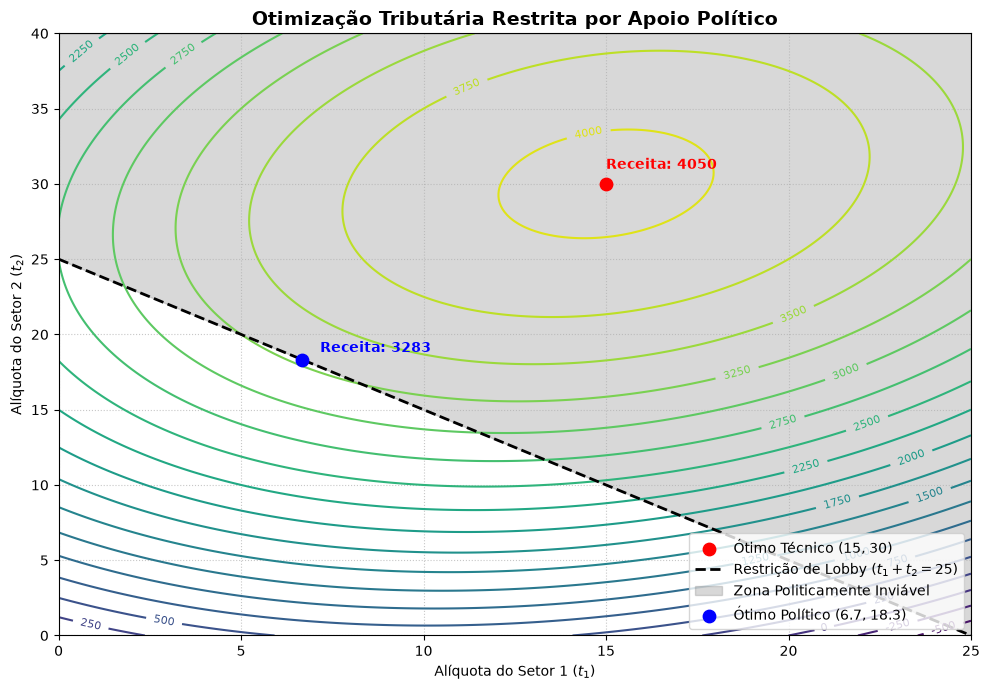

In [21]:
# e) 

# ==========================================
# 1. SOLUÇÃO ANALÍTICA COM LAGRANGE (SYMPY)
# ==========================================

# Definindo as variáveis simbólicas
t1, t2, lam = sp.symbols('t1 t2 lambda')

# Função de arrecadação (objetivo)
R = 120 * t1 + 210 * t2 + 2 * t1 * t2 - 6 * t1**2 - 4 * t2**2

# Restrição Política: t1 + t2 <= 25 (na margem, t1 + t2 = 25)
# g(t1, t2) = 25 - t1 - t2 = 0
g = 25 - t1 - t2

# Função de Lagrange
L = R + lam * g

# Condições de Primeira Ordem (CPO)
dL_dt1 = sp.diff(L, t1)
dL_dt2 = sp.diff(L, t2)
dL_dlam = sp.diff(L, lam)

# Resolvendo o sistema de equações linear (CPO = 0)
solucao = sp.solve([dL_dt1, dL_dt2, dL_dlam], (t1, t2, lam))
t1_pol = float(solucao[t1])
t2_pol = float(solucao[t2])
lam_pol = float(solucao[lam])

# Calculando as arrecadações para comparação
R_irrestrito = 120*15 + 210*30 + 2*15*30 - 6*(15**2) - 4*(30**2)
R_politico = float(R.subs({t1: t1_pol, t2: t2_pol}))

print("--- Solução do Modelo de Economia Política ---")
print(f"Alíquota t1 ótima (restrita) : {t1_pol:.2f}")
print(f"Alíquota t2 ótima (restrita) : {t2_pol:.2f}")
print(f"Multiplicador (lambda)       : {lam_pol:.2f}")
print(f"\nReceita Técnica (Irrestrita) : {R_irrestrito:.2f}")
print(f"Receita Política (Restrita)  : {R_politico:.2f}")
print(f"Custo do Lobby (Perda)       : {R_irrestrito - R_politico:.2f}\n")

# ==========================================
# 2. VISUALIZAÇÃO GRÁFICA (MATPLOTLIB)
# ==========================================

# Criando a malha de valores para plotagem
t1_vals = np.linspace(0, 25, 200)
t2_vals = np.linspace(0, 40, 200)
T1, T2 = np.meshgrid(t1_vals, t2_vals)

# Calculando a superfície da receita original
Z = 120*T1 + 210*T2 + 2*T1*T2 - 6*T1**2 - 4*T2**2

plt.figure(figsize=(10, 7))

# Plotando as curvas de nível de arrecadação
contorno = plt.contour(T1, T2, Z, levels=20, cmap='viridis')
plt.clabel(contorno, inline=True, fontsize=8, fmt='%.0f')

# Plotando o Ponto Ótimo Irrestrito (Técnico)
plt.scatter(15, 30, color='red', zorder=5, s=80, label='Ótimo Técnico (15, 30)')
plt.annotate(f'Receita: {R_irrestrito:.0f}', (15, 31), color='red', weight='bold')

# Plotando a Restrição Política (t1 + t2 = 25 => t2 = 25 - t1)
t2_restricao = 25 - t1_vals
# Limitar o plot da reta para não vazar o gráfico
t2_restricao = np.where(t2_restricao >= 0, t2_restricao, np.nan)
plt.plot(t1_vals, t2_restricao, color='black', linewidth=2, linestyle='--', label='Restrição de Lobby ($t_1 + t_2 = 25$)')

# Preenchendo a área "inviável" politicamente (acima da restrição)
plt.fill_between(t1_vals, t2_restricao, 40, color='gray', alpha=0.3, label='Zona Politicamente Inviável')

# Plotando o Ponto Ótimo Restrito (Político)
plt.scatter(t1_pol, t2_pol, color='blue', zorder=5, s=80, label=f'Ótimo Político ({t1_pol:.1f}, {t2_pol:.1f})')
plt.annotate(f'Receita: {R_politico:.0f}', (t1_pol + 0.5, t2_pol + 0.5), color='blue', weight='bold')

# Configurações de layout
plt.title('Otimização Tributária Restrita por Apoio Político', fontweight='bold', fontsize=14)
plt.xlabel('Alíquota do Setor 1 ($t_1$)')
plt.ylabel('Alíquota do Setor 2 ($t_2$)')
plt.xlim(0, 25)
plt.ylim(0, 40)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### IMPORTANTE!!!!

A resolução por meio do Python tem como objetivo apresentar o uso da economia computacional aplicado aos problemas de economia matemática. Essa prática não substitui o conhecimento das regras e rotinas analíticas necessárias para a álgebra linear, embora constitua um instrumento útil para identificar os efeitos de mudanças de parâmetros e suas respectivas implicações.